In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


In [3]:
df = pd.read_csv('insurance.csv')
Q1 = df['bmi'].quantile(0.25) #using iqr method to remove extreme outliers
Q3 = df['bmi'].quantile(0.75)
IQR = Q3 - Q1
lwoer_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

#Filtering out outliers
df.clean = df[(df['bmi'] >= lwoer_bound) & (df['bmi'] <= upper_bound)].copy()

/tmp/ipykernel_630/798402205.py:9: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.clean = df[(df['bmi'] >= lwoer_bound) & (df['bmi'] <= upper_bound)].copy()


In [4]:
#using one hot encoding to convert 'region' , 'sex', and 'smoker to numerical binary columns
df_clean = pd.get_dummies(df.clean, columns = ['region', 'sex', 'smoker'] ,
drop_first=True)
#smokers with high bmi have exponentially higher insuarance cost
#Creating a new interaction feature by mutiplying the smoker status by bmi to capture the relationship
df_clean['bmi_smoker_interaction'] = df_clean['bmi'] * df_clean['smoker_yes']

#define X features and y target
X = df_clean.drop('charges', axis=1)
y = df_clean['charges']


In [5]:
#spliting the data into training and testing sets (80% train , 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#using standard deviation to normilize the data so all the features contribute equally to the distance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Model Evaluation Metrics:
Mean Squared Error (MSE): 21184833.84536433
R-squared (R2):0.856989


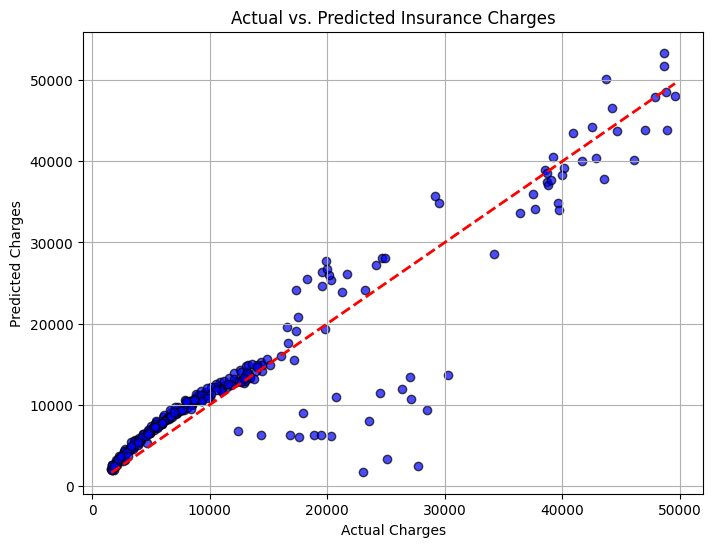

In [6]:
# Implementing mutiple linear regression
model = LinearRegression()
model.fit(X_train_scaled, y_train)

#making the prediction
y_pred = model.predict(X_test_scaled)

#evalutating the peformance
mse = mean_squared_error(y_test, y_pred)
r2 =r2_score(y_test, y_pred)

print('Model Evaluation Metrics:')
print(f'Mean Squared Error (MSE): {mse}')
print(f"R-squared (R2):{r2:4f}")


#Visualizing the regression Plot actual vs predicted to visualize the models accuarcy
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7,
            color='blue', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs. Predicted Insurance Charges')
plt.grid(True)
plt.show()